In [1]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Khurath\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Khurath\AppData\Roaming\nltk_data...


True

In [2]:
df = pd.read_csv("all_tickets.csv")

print(df.columns)
print(df.head())

Index(['Document', 'Topic_group', 'priority'], dtype='object')
                                            Document    Topic_group priority
0  connection with icon icon dear please setup ic...       Hardware      Low
1  work experience user work experience user hi w...         Access      Low
2  requesting for meeting requesting meeting hi p...       Hardware   Medium
3  reset passwords for external accounts re expir...         Access   Medium
4  mail verification warning hi has got attached ...  Miscellaneous      Low


In [3]:
df.rename(columns={
    "Document": "text",
    "Topic_group": "category"
}, inplace=True)


In [4]:
print(df['priority'].value_counts())

priority
Low       23370
Medium    15665
High       8802
Name: count, dtype: int64


In [5]:
df = df.dropna(subset=['text', 'category', 'priority'])

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['text'].astype(str).apply(clean_text)

In [7]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=2
)

X = vectorizer.fit_transform(df['clean_text'])

y_cat = df['category']
y_pri = df['priority']

In [8]:
X_train, X_test, y_train_cat, y_test_cat = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_pri, test_size=0.2, random_state=42, stratify=y_pri
)

In [9]:
category_model = LinearSVC(class_weight='balanced')
category_model.fit(X_train, y_train_cat)

y_pred_cat = category_model.predict(X_test)

print("Category Accuracy:", accuracy_score(y_test_cat, y_pred_cat))
print(classification_report(y_test_cat, y_pred_cat))

Category Accuracy: 0.8500209030100334
                       precision    recall  f1-score   support

               Access       0.88      0.90      0.89      1425
Administrative rights       0.73      0.76      0.74       352
           HR Support       0.87      0.85      0.86      2183
             Hardware       0.84      0.82      0.83      2724
     Internal Project       0.82      0.91      0.86       424
        Miscellaneous       0.81      0.83      0.82      1412
             Purchase       0.92      0.90      0.91       493
              Storage       0.88      0.89      0.88       555

             accuracy                           0.85      9568
            macro avg       0.84      0.86      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



In [10]:
priority_model = LinearSVC(class_weight='balanced')
priority_model.fit(X_train_p, y_train_p)

y_pred_p = priority_model.predict(X_test_p)

print("Priority Accuracy:", accuracy_score(y_test_p, y_pred_p))
print(classification_report(y_test_p, y_pred_p))

Priority Accuracy: 0.9524456521739131
              precision    recall  f1-score   support

        High       0.95      0.88      0.91      1761
         Low       0.95      0.99      0.97      4674
      Medium       0.96      0.93      0.95      3133

    accuracy                           0.95      9568
   macro avg       0.95      0.94      0.94      9568
weighted avg       0.95      0.95      0.95      9568



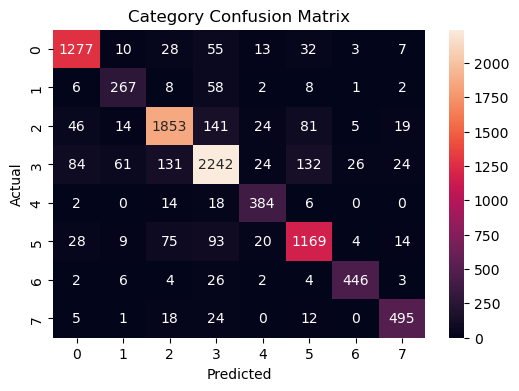

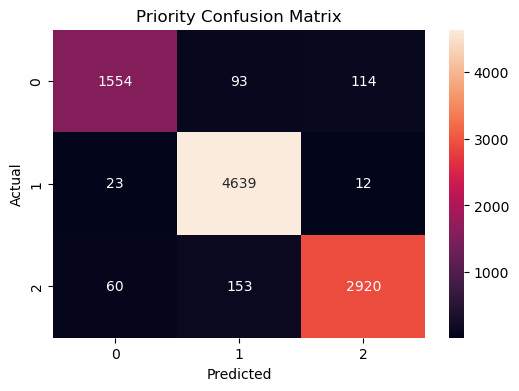

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_cat), annot=True, fmt='d')
plt.title("Category Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_p, y_pred_p), annot=True, fmt='d')
plt.title("Priority Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
feature_names = vectorizer.get_feature_names_out()
coefs = category_model.coef_

for i, category in enumerate(category_model.classes_):
    top10 = np.argsort(coefs[i])[-10:]
    print(f"\nTop words for {category}:")
    print([feature_names[j] for j in top10])


Top words for Access:
['access card', 'locked', 'card', 'password', 'user', 'license', 'git', 'repository', 'account', 'confluence']

Top words for Administrative rights:
['version', 'window', 'asset', 'issue', 'outlook sent', 'install', 'software', 'exchange', 'upgrade', 'outlook']

Top words for HR Support:
['bucharest', 'timecard', 'submit', 'time', 'leaver', 'error', 'leave', 'starter', 'time card', 'oracle']

Top words for Hardware:
['backpack', 'meeting', 'call', 'certificate', 'phone', 'room', 'connection', 'laptop', 'ram', 'monitor']

Top words for Internal Project:
['set', 'known', 'import', 'pa', 'unknown', 'pipe', 'setup', 'project', 'pipeline', 'code']

Top words for Miscellaneous:
['approver', 'name', 'owner', 'approved', 'add', 'change', 'approve', 'ticket', 'group', 'approval']

Top words for Purchase:
['replenishment', 'glass', 'item', 'allocation', 'device', 'receipt', 'administrator', 'po', 'installation', 'purchase']

Top words for Storage:
['file', 'increase', 'acc

In [13]:
def final_predict(ticket):
    cleaned = clean_text(ticket)
    vec = vectorizer.transform([cleaned])

    category = category_model.predict(vec)[0]
    priority = priority_model.predict(vec)[0]

    print("\n========================")
    print("Ticket:", ticket)
    print("Category:", category)
    print("Priority:", priority)
    print("========================")

# Test
final_predict("My laptop is not working and shows error")
final_predict("Laptop overheating urgently fix")
final_predict("Password reset is not working for my account")
final_predict("How can I update my profile details?")
final_predict("System is very slow today")


Ticket: My laptop is not working and shows error
Category: Hardware
Priority: High

Ticket: Laptop overheating urgently fix
Category: Hardware
Priority: High

Ticket: Password reset is not working for my account
Category: Access
Priority: Low

Ticket: How can I update my profile details?
Category: Administrative rights
Priority: Low

Ticket: System is very slow today
Category: Hardware
Priority: Medium
